In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

"This is another of those films I can remember from when I was a kid and I recently managed to acquire it off ebay - 20 years on, it's nowhere near as good as I remember it being.<br /><br />The story is 'vaguely' kick started, by a 'cosmic event' (there's another extra film-crew member in the credits for 'weak story development') which makes collective ants become super intelligent. Ant species who used to war with each other have ceased rivalries and are now working together. The thing I wanted to know throughout was, TO DO WHAT EXACTLY? You never find out what they want. Nigel Davenport and his sidekick travel out to the desert where bizarre ant activity has been noted, and begin to study the ants from an impregnable igloo shaped laboratory. Probably the most chilling scene in my opinion was when the two scientists visit the giant square in the crops (like a square version of a crop circle) a result of the ants chomping away.<br /><br />This film was not very scary quite simply beca

In [5]:
print(preprocess(df.iloc[random_num]['review']))

another film remember kid recently managed acquire ebay year nowhere near good remember story vaguely kick started cosmic event another extra film crew member credit weak story development make collective ant become super intelligent ant specie used war ceased rivalry working together thing wanted know throughout exactly never find want nigel davenport sidekick travel desert bizarre ant activity noted begin study ant impregnable igloo shaped laboratory probably chilling scene opinion two scientist visit giant square crop like square version crop circle result ant chomping away film scary quite simply know whether fear ant like know ant want people leave area get hijinks find whether really baddie sci cosmic event explanation vague properly taken account deffo chiller honest flare daft hairstyle tight shirt big collar nigel davenport unnaturally big facial hair freaked ant notice six actor listed credit yup right six see human being film even distance plainly obviously low budget film b

In [ ]:
df['review'] = df['review'].apply(preprocess)

In [ ]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [ ]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [ ]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
max_len = 20

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [ ]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(16, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(16, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 4)          │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 20, 4)          │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,633 (318.88 KB)

 Trainable params: 81,633 (318.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [49]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5497 - loss: 0.6827 - val_accuracy: 0.7034 - val_loss: 0.5967 - learning_rate: 5.0000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7226 - loss: 0.5590 - val_accuracy: 0.7742 - val_loss: 0.4796 - learning_rate: 5.0000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7804 - loss: 0.4804 - val_accuracy: 0.7924 - val_loss: 0.4422 - learning_rate: 5.0000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8055 - loss: 0.4373 - val_accuracy: 0.7999 - val_loss: 0.4343 - learning_rate: 5.0000e-04
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8198 - loss: 0.4127 - val_accuracy: 0.7986 - val_loss: 0.4358 - learning_rate: 5.0000e-04


In [50]:
lstm_model.save_weights("lstm_modelo_leve.weights.h5")

In [51]:

lstm_model.load_weights("lstm_modelo_leve.weights.h5")

In [52]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [53]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8000 - loss: 0.4266
Test Accuracy: 0.800000011920929


# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


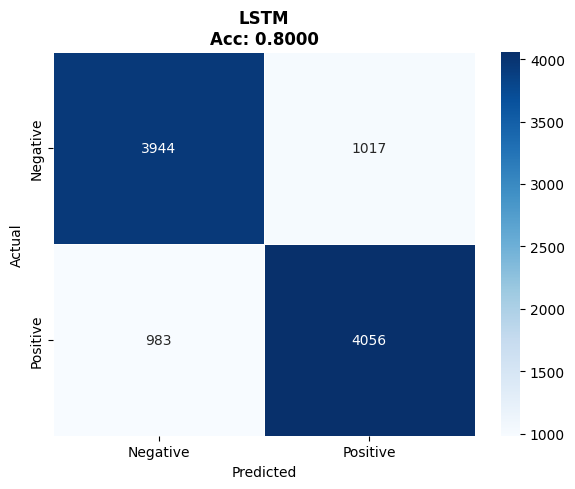

In [54]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [55]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80      4961
    Positive       0.80      0.80      0.80      5039

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



# Teste de Outputs


In [58]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[0].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step
Outputs salvos em layer_outputs_simplified_model.txt


# Exportação de Pesos

In [60]:
export_weights(lstm_model, mode='lstm', output_file="weights_lstm_small.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_input[0][0] = -0.263048
  addr=0x08001 Wx_input[0][1] = -0.170090
  addr=0x08080 Wx_input[1][0] = -0.230196
  addr=0x08081 Wx_input[1][1] = 0.157502
  addr=0x08040 Wh_input[0][0] = 0.006687
  addr=0x08041 Wh_input[0][1] = 0.072310
  addr=0x080C0 Wh_input[1][0] = 0.170767
  addr=0x080C1 Wh_input[1][1] = -0.218241
  addr=0x18000 bias_input[0] = 0.077643
  addr=0x18080 bias_input[1] = 0.086867
  addr=0x0A000 Wx_forget[0][0] = -0.297708
  addr=0x0A001 Wx_forget[0][1] = -0.281061
  addr=0x0A080 Wx_forget[1][0] = -0.303796
  addr=0x0A081 Wx_forget[1][1] = -0.172184
  addr=0x0A040 Wh_forget[0][0] = 0.073705
  addr=0x0A041 Wh_forget[0][1] = -0.033270
  addr=0x0A0C0 Wh_forget[1][0] = -0.004481
  addr=0x0A0C1 Wh_forget[1][1] = -0.082596
  addr=0x1A000 bias_forget[0] = 1.052547
  addr=0x1A080 bias_forget[1] = 1.012772
  addr=0x0C000 Wx_candidate[0][0] = -0.300348
  addr

# Teste Global

In [61]:
FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [62]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q16 = float_to_q16(valor)  # sua função original
            mem[addr] = valor_q16
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q16(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [ ]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
#total = len(y_pred_lstm)
total = 10

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"../../Geral Tests SystemVerilog/Small Neural Network/Small Global Processing/dados_{i}.mem")

    print(f"{i} de {total}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
Arquivo salvo: Small Global Processing/dados_0.mem
0 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Arquivo salvo: Small Global Processing/dados_1.mem
1 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Arquivo salvo: Small Global Processing/dados_2.mem
2 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Arquivo salvo: Small Global Processing/dados_3.mem
3 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Arquivo salvo: Small Global Processing/dados_4.mem
4 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Arquivo salvo: Small Global Processing/dados_5.mem
5 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Arquivo salvo: Small Global Processing/dados_6.mem
6 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Arquivo salvo: Small Global Processing/dados_7.mem
7 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Arquivo salvo: Small Global Processing/dados_8.mem
8 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Arquivo salvo: Small Global Processing/dados_9.mem
9 de 100
1/1 ━━━━━━━━━━━━━━━